In [2]:
import pandas as pd
data = pd.read_csv('../dataset/TUANDROMD 2.csv')
data

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,malware
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,malware
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,malware
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4460,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,goodware
4461,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,goodware
4462,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,goodware
4463,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,goodware


In [3]:
# Cek jumlah missing value awal
print(data.isna().sum())

# Hapus baris dengan missing value dan simpan hasilnya
data = data.dropna()

# Cek kembali jumlah missing value setelah dihapus
print(data.isna().sum())

ACCESS_ALL_DOWNLOADS                                        1
ACCESS_CACHE_FILESYSTEM                                     1
ACCESS_CHECKIN_PROPERTIES                                   1
ACCESS_COARSE_LOCATION                                      1
ACCESS_COARSE_UPDATES                                       1
                                                           ..
Landroid/telephony/TelephonyManager;->getSimOperatorName    1
Landroid/telephony/TelephonyManager;->getSimCountryIso      1
Landroid/telephony/TelephonyManager;->getSimSerialNumber    1
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    1
Label                                                       1
Length: 242, dtype: int64
ACCESS_ALL_DOWNLOADS                                        0
ACCESS_CACHE_FILESYSTEM                                     0
ACCESS_CHECKIN_PROPERTIES                                   0
ACCESS_COARSE_LOCATION                                      0
ACCESS_COARSE_UPDATES                       

In [4]:
data['Label'].value_counts()

Label
malware     3565
goodware     899
Name: count, dtype: int64

In [5]:
# Mapping label
data["Label"] = data["Label"].map({
    "goodware": 0,
    "malware": 1
})

# Cek distribusi kelas
print(data["Label"].value_counts())

Label
1    3565
0     899
Name: count, dtype: int64


In [6]:
# Menghitung jumlah kolom per tipe data
print(data.dtypes.value_counts())

float64    241
int64        1
Name: count, dtype: int64


In [7]:
# Memisahkan Fitur (X) dan Label (y)
X = data.drop(columns=["Label"])
y = data["Label"]

# Cek dimensi/ukuran data hasil pemisahan
print("Ukuran Fitur (X):", X.shape)
print("Ukuran Label (y):", y.shape)

Ukuran Fitur (X): (4464, 241)
Ukuran Label (y): (4464,)


In [8]:
# %%
from sklearn.model_selection import train_test_split

# Split pertama: Train + Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split kedua: Validation + Test
# Dari 30% temporary:
# 15% validation + 15% test dari total dataset
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape, y_val.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (3124, 241) (3124,)
Val   : (670, 241) (670,)
Test  : (670, 241) (670,)


In [9]:
# %%
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Val  :", X_val_scaled.shape)
print("Test :", X_test_scaled.shape)

Train: (3124, 241)
Val  : (670, 241)
Test : (670, 241)


In [10]:
# %%
import torch

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

print("X_train:", X_train_t.shape)
print("y_train:", y_train_t.shape)

X_train: torch.Size([3124, 241])
y_train: torch.Size([3124])


In [11]:
# %%
from model import build_model
input_dim = X_train_t.shape[1]

model = build_model(
    in_dim=input_dim,
    num_classes=2,
    seed=42
)

print(model)

DrebinModel(
  (theta): FeatureExtractor(
    (fc1): Linear(in_features=241, out_features=64, bias=True)
    (relu1): ReLU()
    (fc2): Linear(in_features=64, out_features=32, bias=True)
    (relu2): ReLU()
  )
  (phi): ClassifierHead(
    (fc): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [12]:
# %%
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

num_epochs = 20

for epoch in range(num_epochs):

    # =========================
    # TRAIN
    # =========================
    model.train()

    optimizer.zero_grad()

    logits = model(X_train_t)

    loss = criterion(logits, y_train_t)

    loss.backward()

    optimizer.step()

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    with torch.no_grad():

        val_logits = model(X_val_t)

        val_loss = criterion(
            val_logits,
            y_val_t
        )

        val_pred = torch.argmax(
            val_logits,
            dim=1
        )

        val_acc = (
            val_pred == y_val_t
        ).float().mean()

    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch [{epoch+1:03d}/{num_epochs}] "
            f"Train Loss: {loss.item():.4f} "
            f"Val Loss: {val_loss.item():.4f} "
            f"Val Acc: {val_acc.item():.4f}"
        )

Epoch [005/20] Train Loss: 0.5965 Val Loss: 0.5826 Val Acc: 0.7985
Epoch [010/20] Train Loss: 0.5178 Val Loss: 0.5017 Val Acc: 0.8000
Epoch [015/20] Train Loss: 0.4290 Val Loss: 0.4124 Val Acc: 0.8358
Epoch [020/20] Train Loss: 0.3374 Val Loss: 0.3242 Val Acc: 0.8687


In [13]:
# %%
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)

    test_pred = torch.argmax(
        test_logits,
        dim=1
    )

y_true = y_test_t.numpy()
y_pred = test_pred.numpy()

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="binary"
)

recall = recall_score(
    y_true,
    y_pred,
    average="binary"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="binary"
)

print("Test Accuracy :", accuracy)
print("Test Precision:", precision)
print("Test Recall   :", recall)
print("Test F1       :", f1)

Test Accuracy : 0.8582089552238806
Test Precision: 0.8525641025641025
Test Recall   : 0.994392523364486
Test F1       : 0.9180327868852459


In [14]:
# %%
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["B", "S"]
    )
)

              precision    recall  f1-score   support

           B       0.93      0.32      0.48       135
           S       0.85      0.99      0.92       535

    accuracy                           0.86       670
   macro avg       0.89      0.66      0.70       670
weighted avg       0.87      0.86      0.83       670



In [15]:
# %%
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 43  92]
 [  3 532]]


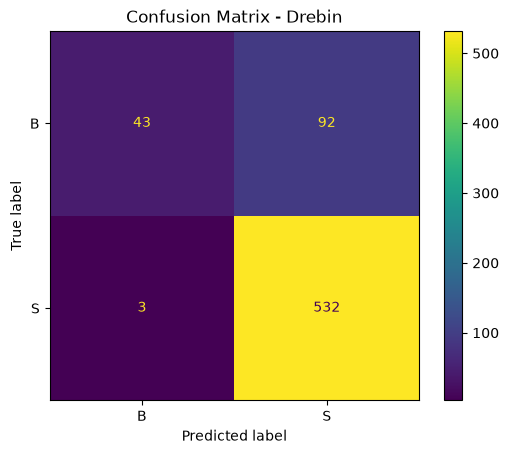

In [16]:
# %%
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["B", "S"]
)

disp.plot()

plt.title("Confusion Matrix - Drebin")
plt.show()